In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



In [17]:
turnover = pd.read_csv('../turnover.csv', encoding ='ISO-8859-1')

In [18]:
turnover.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1129 entries, 0 to 1128
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   stag          1129 non-null   float64
 1   event         1129 non-null   int64  
 2   gender        1129 non-null   object 
 3   age           1129 non-null   float64
 4   industry      1129 non-null   object 
 5   profession    1129 non-null   object 
 6   traffic       1129 non-null   object 
 7   coach         1129 non-null   object 
 8   head_gender   1129 non-null   object 
 9   greywage      1129 non-null   object 
 10  way           1129 non-null   object 
 11  extraversion  1129 non-null   float64
 12  independ      1129 non-null   float64
 13  selfcontrol   1129 non-null   float64
 14  anxiety       1129 non-null   float64
 15  novator       1129 non-null   float64
dtypes: float64(7), int64(1), object(8)
memory usage: 141.3+ KB


In [19]:
turnover

,stag,event,gender,age,industry,profession,traffic,coach,head_gender,greywage,way,extraversion,independ,selfcontrol,anxiety,novator
0,7.030801,1,m,35.0,Banks,HR,rabrecNErab,no,f,white,bus,6.2,4.1,5.7,7.1,8.3
1,22.965092,1,m,33.0,Banks,HR,empjs,no,m,white,bus,6.2,4.1,5.7,7.1,8.3
2,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,6.2,6.2,2.6,4.8,8.3
3,15.934292,1,f,35.0,PowerGeneration,HR,rabrecNErab,no,m,white,bus,5.4,7.6,4.9,2.5,6.7
4,8.410678,1,m,32.0,Retail,Commercial,youjs,yes,f,white,bus,3.0,4.1,8.0,7.1,3.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124,10.611910,0,f,41.0,Banks,HR,rabrecNErab,my head,m,white,bus,8.6,3.4,2.6,4.8,8.3
1125,10.611910,0,f,41.0,Banks,HR,rabrecNErab,my head,m,white,bus,8.6,3.4,2.6,4.8,8.3
1126,118.800821,0,f,34.0,Telecom,Accounting,KA,no,f,white,bus,4.6,5.5,7.2,6.3,3.7
1127,49.412731,0,f,51.0,Consult,HR,empjs,no,m,grey,bus,3.8,7.6,5.7,6.3,5.2


In [20]:
turnover.describe()

,stag,event,age,extraversion,independ,selfcontrol,anxiety,novator
count,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000,1129.000000
mean,36.627526,0.505757,31.066965,5.592383,5.478034,5.597254,5.665633,5.879628
std,34.096597,0.500188,6.996147,1.851637,1.703312,1.980101,1.709176,1.904016
min,0.394251,0.000000,18.000000,1.000000,1.000000,1.000000,1.700000,1.000000
25%,11.728953,0.000000,26.000000,4.600000,4.100000,4.100000,4.800000,4.400000
50%,24.344969,1.000000,30.000000,5.400000,5.500000,5.700000,5.600000,6.000000
75%,51.318275,1.000000,36.000000,7.000000,6.900000,7.200000,7.100000,7.500000
max,179.449692,1.000000,58.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [21]:
turnover.isna().sum()

stag            0
event           0
gender          0
age             0
industry        0
profession      0
traffic         0
coach           0
head_gender     0
greywage        0
way             0
extraversion    0
independ        0
selfcontrol     0
anxiety         0
novator         0
dtype: int64

In [22]:
turnover.duplicated().sum()

np.int64(13)

In [23]:
turnover = turnover.drop_duplicates()

In [24]:
from sklearn.preprocessing import LabelEncoder
print('Categorical columns: ')
for col in turnover.columns:
    if turnover[col].dtype == 'object':
        values = turnover[col].value_counts()
        values = dict(values)

        print(str(col))
        label = LabelEncoder()
        label = label.fit(turnover[col])
        turnover.loc[:, col] = label.transform(turnover[col].astype(str))

        new_values = turnover[col].value_counts()
        new_values = dict(new_values)

        value_dict = {}
        i=0
        for key in values:
            value_dict[key] = list(new_values)[i]
            i+= 1
        print(value_dict)

Categorical columns: 
gender
{'f': 0, 'm': 1}
industry
{'Retail': 10, 'manufacture': 14, 'IT': 5, 'Banks': 2, 'etc': 13, 'Consult': 4, 'State': 11, 'Building': 3, 'transport': 15, 'PowerGeneration': 8, 'Telecom': 12, 'Mining': 6, 'Pharma': 7, 'Agriculture': 1, 'RealEstate': 9, ' HoReCa': 0}
profession
{'HR': 6, 'IT': 7, 'Sales': 11, 'etc': 13, 'Marketing': 9, 'BusinessDevelopment': 1, 'Consult': 3, 'Commercial': 2, 'manage': 14, 'Finanñe': 5, 'Engineer': 4, 'Teaching': 12, 'Accounting': 0, 'Law': 8, 'PR': 10}
traffic
{'youjs': 7, 'empjs': 2, 'rabrecNErab': 4, 'friends': 3, 'referal': 6, 'KA': 0, 'recNErab': 5, 'advert': 1}
coach
{'no': 1, 'my head': 0, 'yes': 2}
head_gender
{'m': 1, 'f': 0}
greywage
{'white': 1, 'grey': 0}
way
{'bus': 0, 'car': 1, 'foot': 2}


In [25]:
cat_cols = [col for col in turnover.columns if turnover[col].dtype == 'object']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X = turnover.drop(columns=['event'])
y = turnover['event']
X_transformed = preprocessor.fit_transform(X)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
def evaluate_model(y_pred, y_true):
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()



=== Logistic Regression ===
Accuracy: 0.6339
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.68      0.65       112
           1       0.65      0.59      0.62       112

    accuracy                           0.63       224
   macro avg       0.64      0.63      0.63       224
weighted avg       0.64      0.63      0.63       224



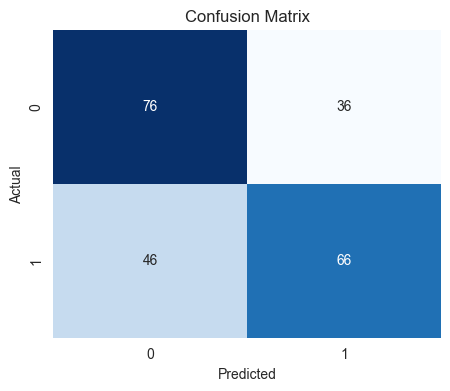


=== SVM (Poly Kernel) ===
Accuracy: 0.5268
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.08      0.15       112
           1       0.51      0.97      0.67       112

    accuracy                           0.53       224
   macro avg       0.63      0.53      0.41       224
weighted avg       0.63      0.53      0.41       224



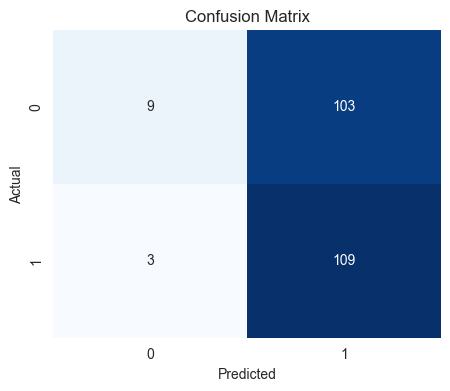


=== Decision Tree ===
Accuracy: 0.5893
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.61      0.60       112
           1       0.59      0.57      0.58       112

    accuracy                           0.59       224
   macro avg       0.59      0.59      0.59       224
weighted avg       0.59      0.59      0.59       224



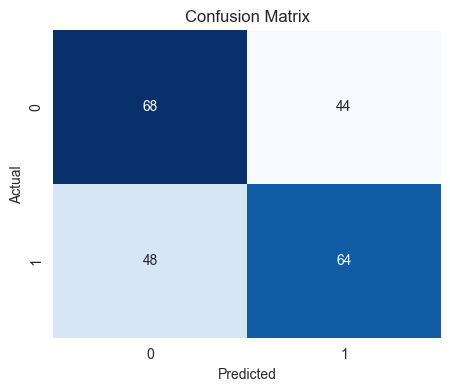


=== K-Nearest Neighbors ===
Accuracy: 0.5804
Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.62      0.60       112
           1       0.59      0.54      0.56       112

    accuracy                           0.58       224
   macro avg       0.58      0.58      0.58       224
weighted avg       0.58      0.58      0.58       224



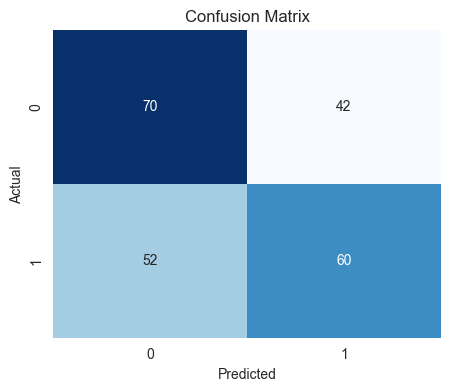


=== Random Forest ===
Accuracy: 0.6696
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.69      0.68       112
           1       0.68      0.65      0.66       112

    accuracy                           0.67       224
   macro avg       0.67      0.67      0.67       224
weighted avg       0.67      0.67      0.67       224



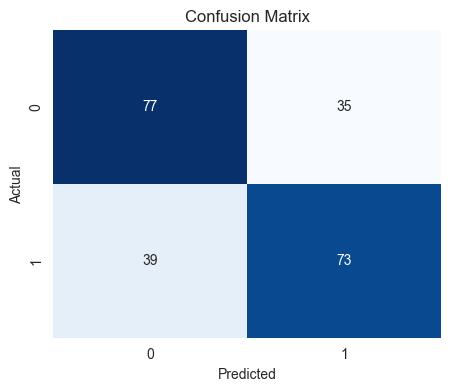


=== Extra Trees ===
Accuracy: 0.6250
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64       112
           1       0.64      0.58      0.61       112

    accuracy                           0.62       224
   macro avg       0.63      0.62      0.62       224
weighted avg       0.63      0.62      0.62       224



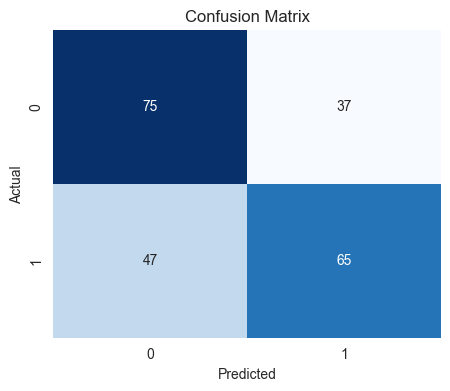


=== AdaBoost ===
Accuracy: 0.5670
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.67      0.61       112
           1       0.58      0.46      0.52       112

    accuracy                           0.57       224
   macro avg       0.57      0.57      0.56       224
weighted avg       0.57      0.57      0.56       224



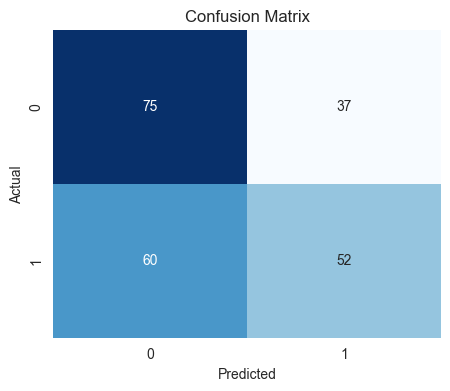


=== Gradient Boosting ===
Accuracy: 0.6786
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       112
           1       0.70      0.62      0.66       112

    accuracy                           0.68       224
   macro avg       0.68      0.68      0.68       224
weighted avg       0.68      0.68      0.68       224



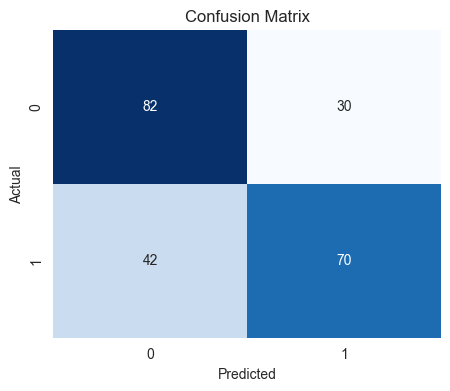

In [28]:
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, solver='lbfgs'    )),
    ("SVM (Poly Kernel)", SVC(kernel='poly')),
    ("Decision Tree", DecisionTreeClassifier()),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Random Forest", RandomForestClassifier()),
    ("Extra Trees", ExtraTreesClassifier()),
    ("AdaBoost", AdaBoostClassifier()),
    ("Gradient Boosting", GradientBoostingClassifier())
]

for name, model in models:
    print(f"\n=== {name} ===")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    evaluate_model(y_pred, y_test)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVC (Poly Kernel)": SVC(kernel='poly', degree=3),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

# Evaluate each
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
1    SVC (Poly Kernel)  0.526786   0.514151  0.973214  0.672840
4        Random Forest  0.674107   0.693069  0.625000  0.657277
0  Logistic Regression  0.633929   0.647059  0.589286  0.616822
2        Decision Tree  0.607143   0.607143  0.607143  0.607143
3  K-Nearest Neighbors  0.580357   0.588235  0.535714  0.560748
5             AdaBoost  0.566964   0.584270  0.464286  0.517413
